# Household Energy Consumption Prediction — Complete Regression Notebook

**Goal:** Build, tune, evaluate, and compare all 10 regression algorithms required by the ML capstone.

**Target:** `Appliances`

**Required algorithms**
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Elastic Net
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor

The same preprocessed data and the same held-out 80:20 test split are used for all ten models. The preprocessing also keeps learned operations such as scaling and IQR bounds based on the training data only.

## 1. Imports and reproducibility

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the dataset

Place `energydata.csv` in the same folder as this notebook before running it.

In [5]:
DATA_PATH = "energydata.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 3. Dataset audit

In [6]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe().T)

Data types:


,dtype
date,object
Appliances,int64
lights,int64
T1,float64
RH_1,float64
T2,float64
RH_2,float64
T3,float64
RH_3,float64
T4,float64



Missing values:


,missing_values
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0



Duplicate rows: 0

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


## 4. Target distribution

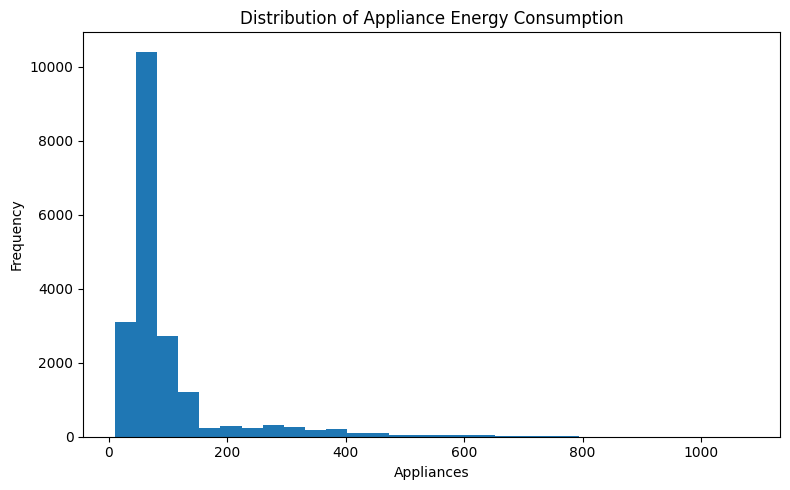

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["Appliances"], bins=30)
plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Appliances")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis — feature distributions

The capstone rubric asks for distribution plots for the features. The following cell creates one clearly labelled histogram per numerical feature.

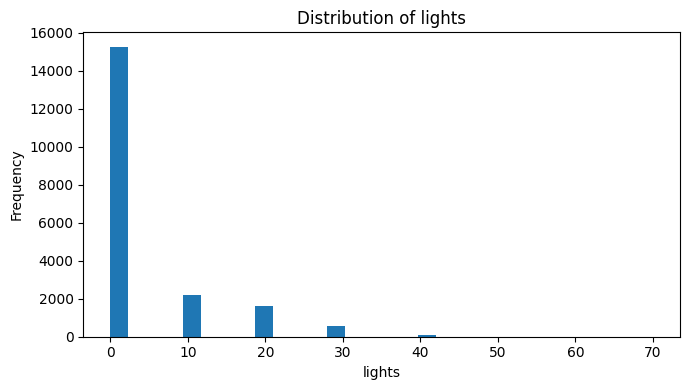

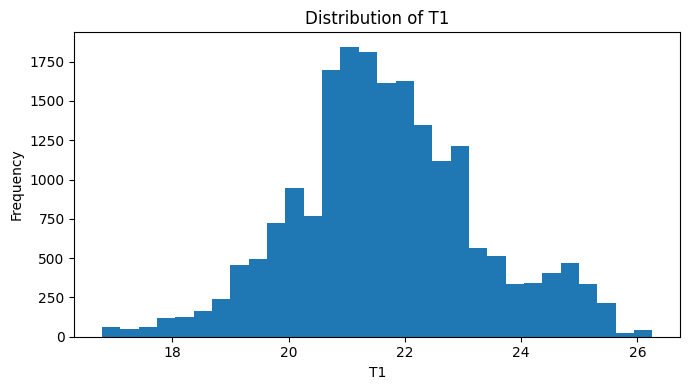

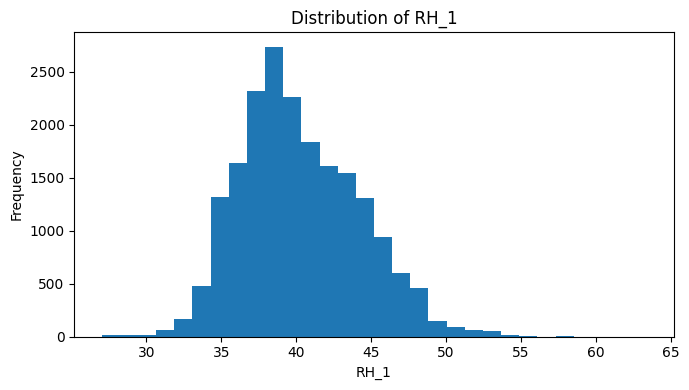

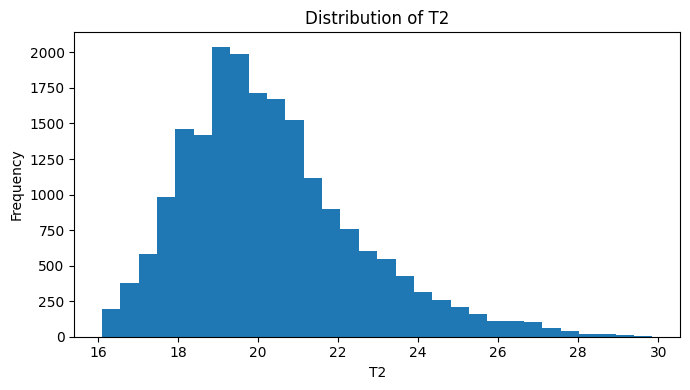

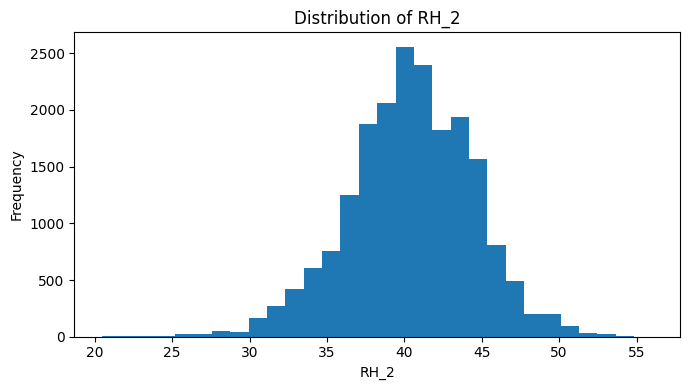

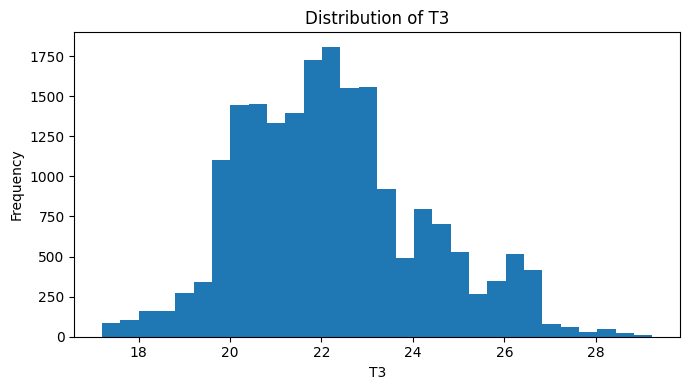

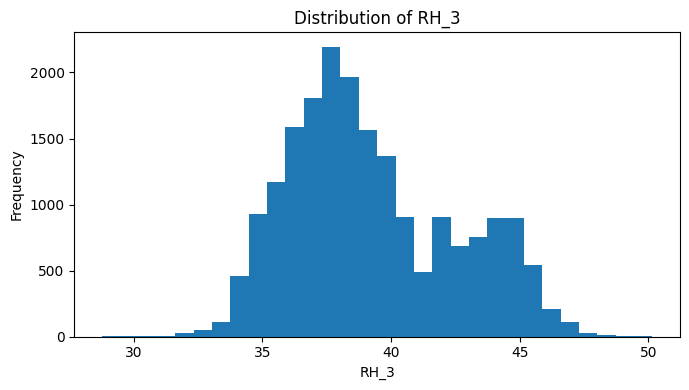

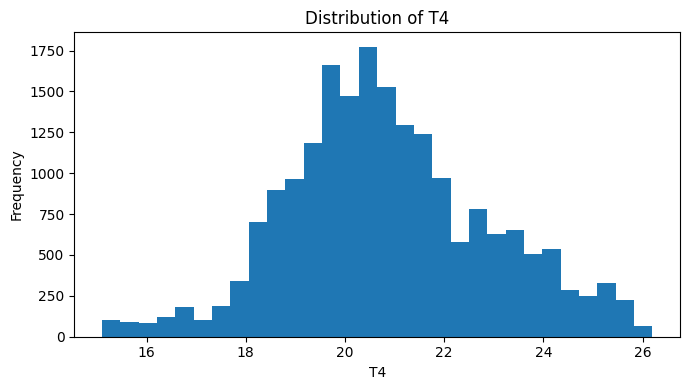

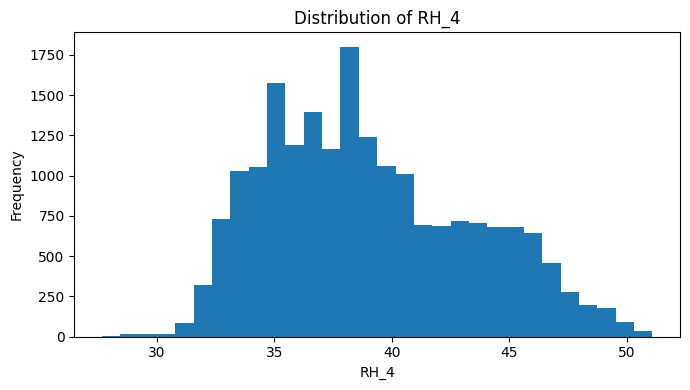

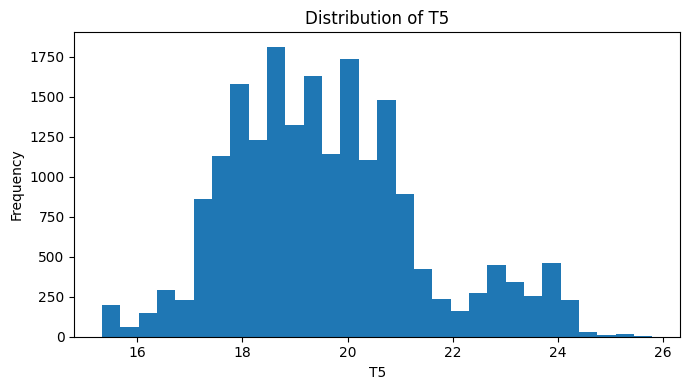

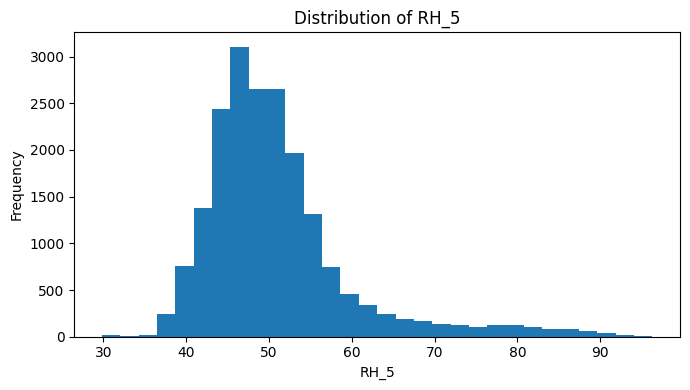

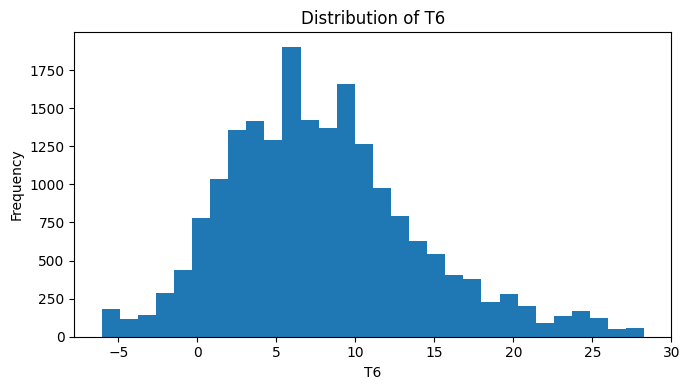

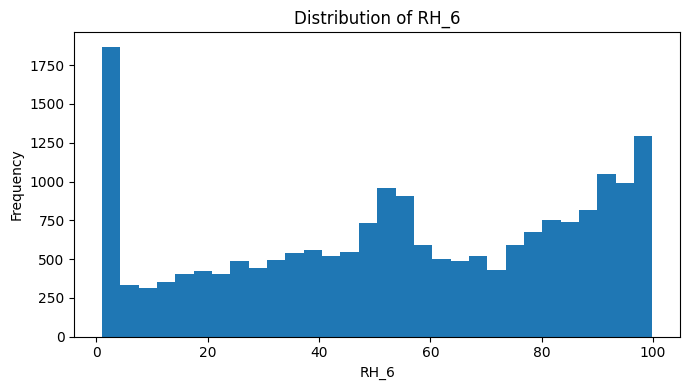

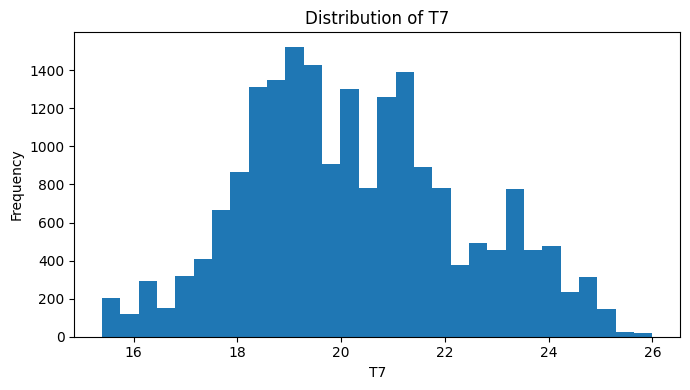

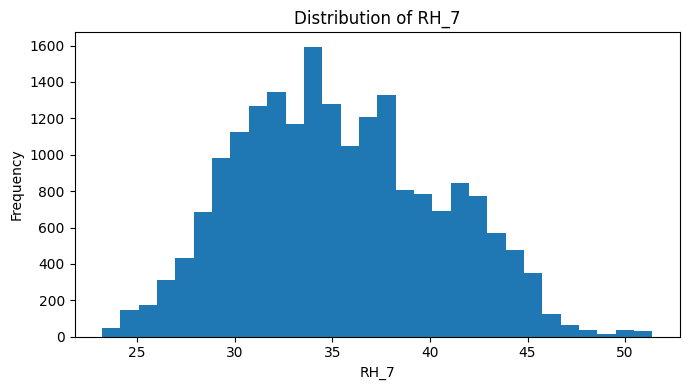

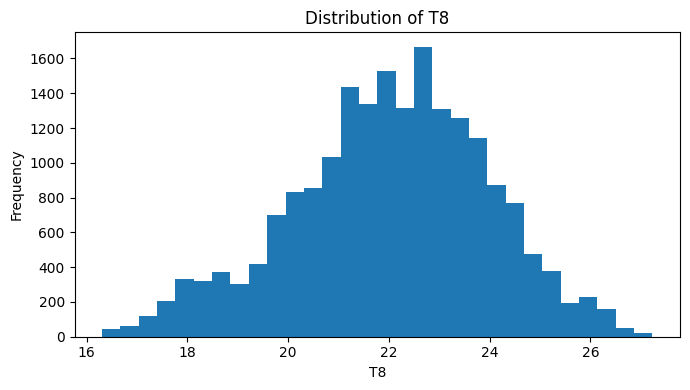

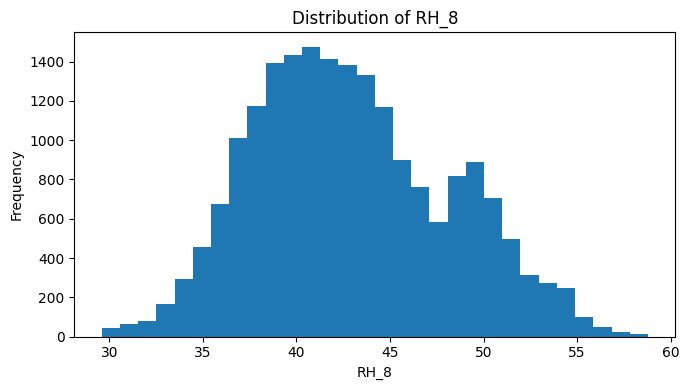

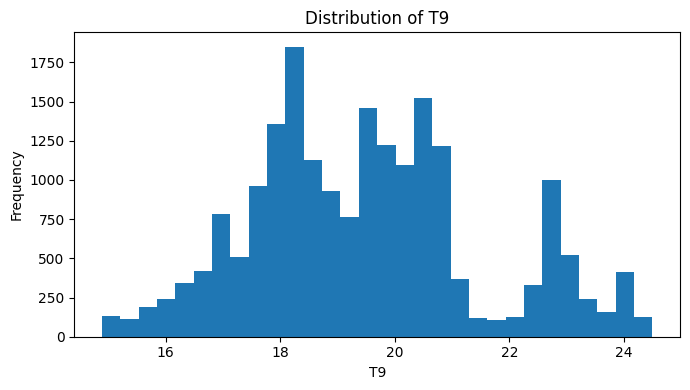

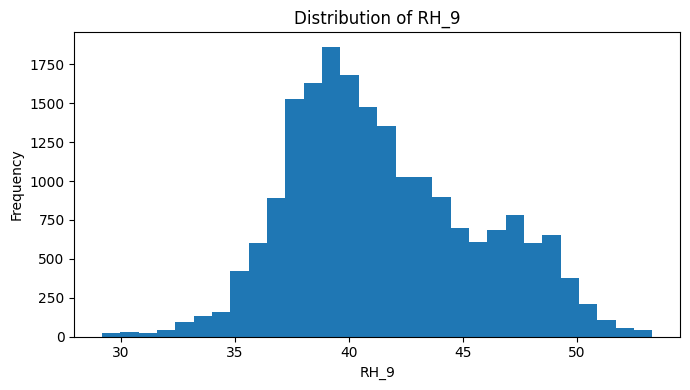

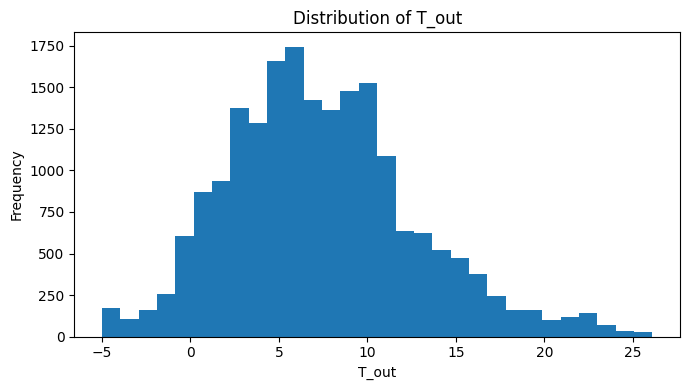

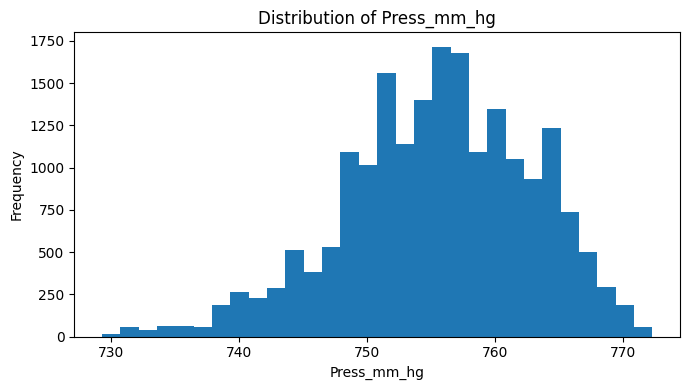

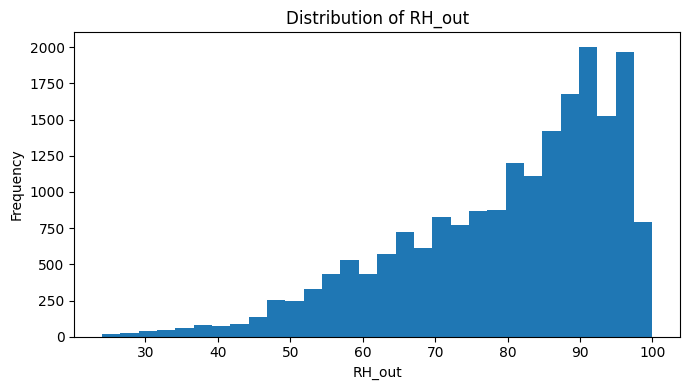

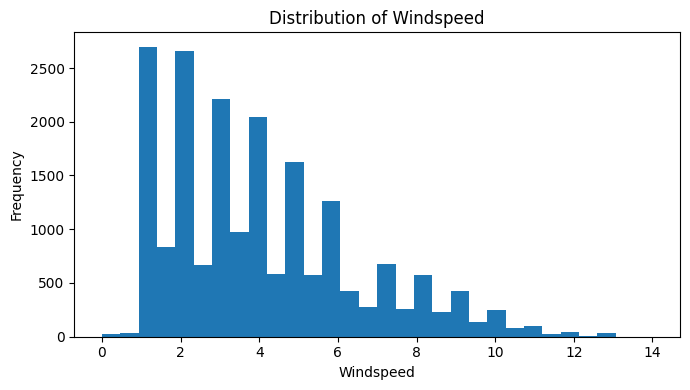

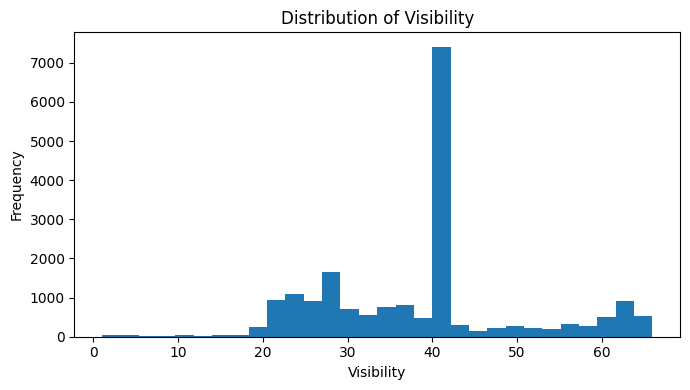

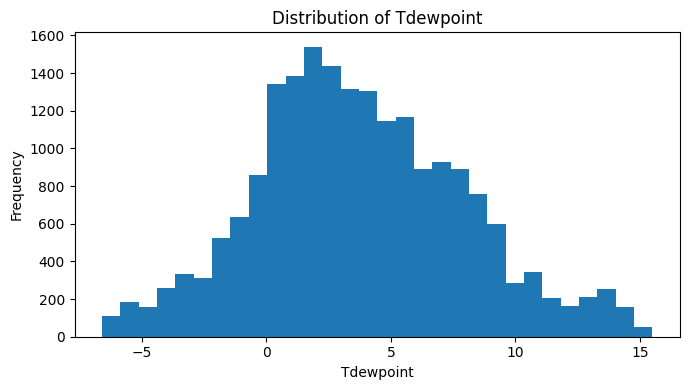

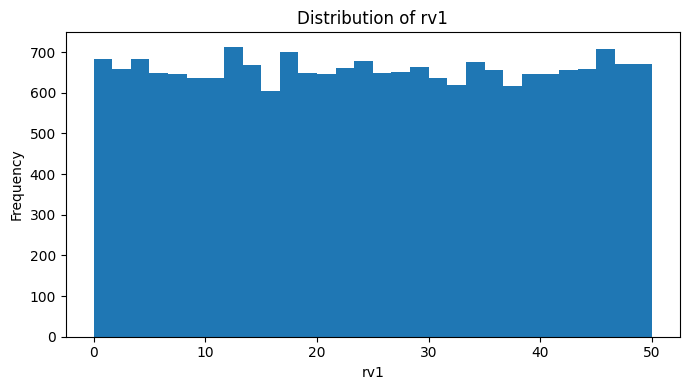

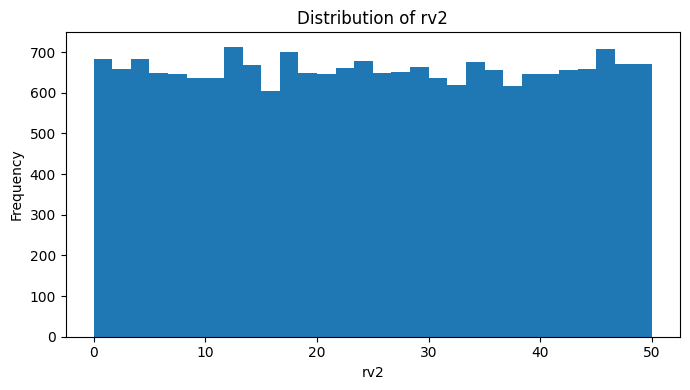

In [8]:
numeric_features_original = df.select_dtypes(include=np.number).columns.tolist()

for feature in numeric_features_original:
    if feature == "Appliances":
        continue
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature].dropna(), bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 6. Correlation heatmap

Correlation is inspected before modelling to understand linear relationships among variables and with the target.

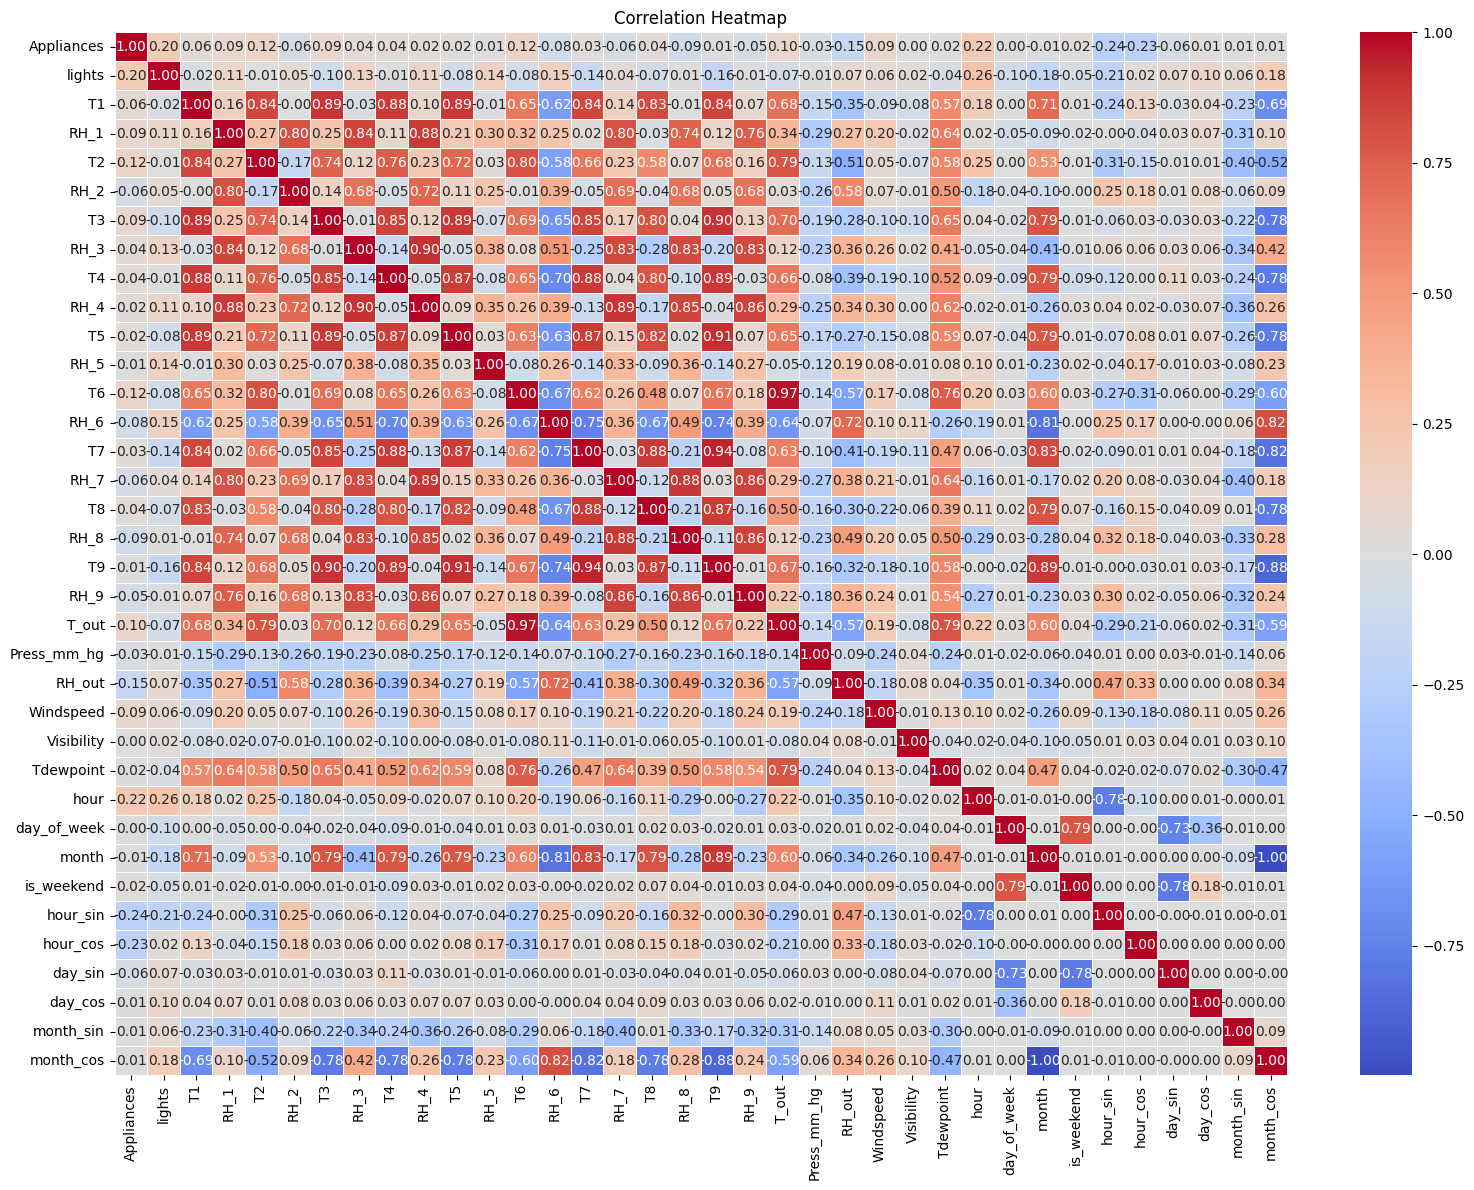

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Feature–target relationships

Two scatter plots are shown as required by the rubric.

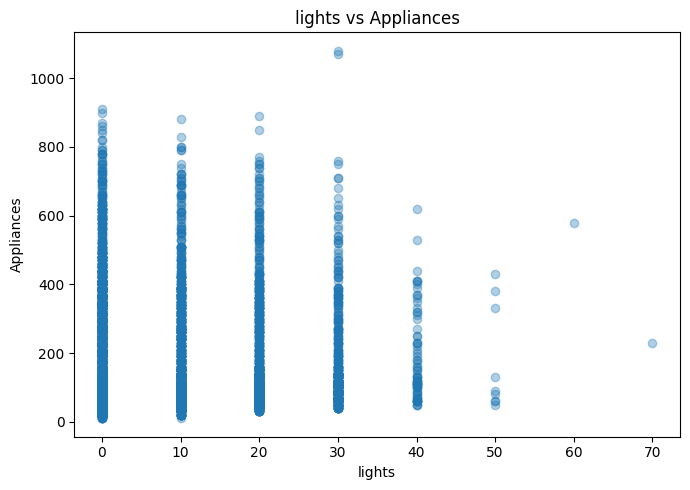

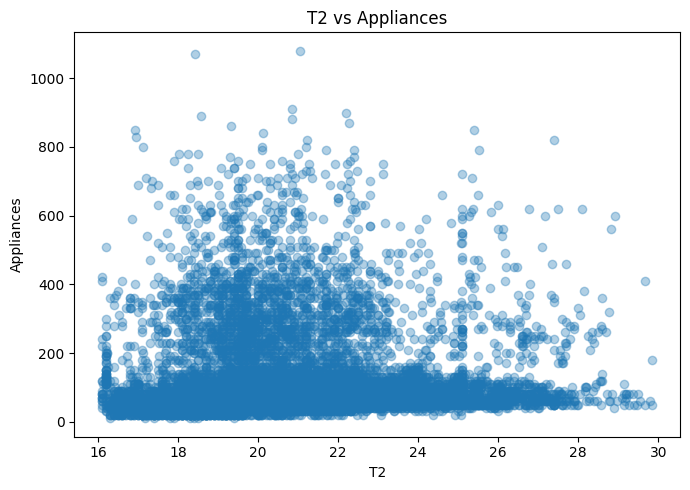

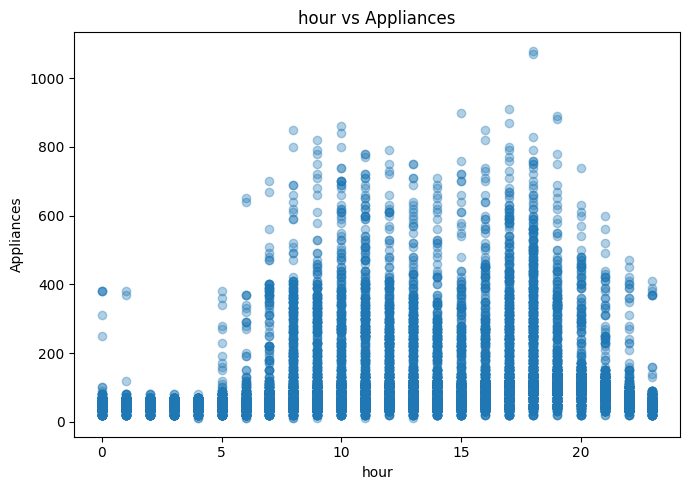

In [42]:
scatter_features = ["lights", "T2","hour"]

for feature in scatter_features:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[feature], df["Appliances"], alpha=0.35)
    plt.title(f"{feature} vs Appliances")
    plt.xlabel(feature)
    plt.ylabel("Appliances")
    plt.tight_layout()
    plt.show()

In [ ]:
corr_with_target = (
    df.select_dtypes(include=np.number)
      .corr()["Appliances"]
      .drop("Appliances")
      .sort_values(key=abs, ascending=False)
)

print(corr_with_target)

hour_sin      -0.235233
hour_cos      -0.232125
hour           0.216792
lights         0.197278
RH_out        -0.152282
T2             0.120073
T6             0.117638
T_out          0.099155
RH_8          -0.094039
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
RH_6          -0.083178
RH_2          -0.060465
day_sin       -0.056045
RH_7          -0.055642
T1             0.055447
RH_9          -0.051462
T4             0.040281
T8             0.039572
RH_3           0.036292
Press_mm_hg   -0.034885
T7             0.025801
T5             0.019760
is_weekend     0.017437
RH_4           0.016965
Tdewpoint      0.015353
month_sin      0.012703
month_cos      0.011631
month         -0.011606
day_cos        0.010717
T9             0.010010
RH_5           0.006955
day_of_week    0.003060
Visibility     0.000230
Name: Appliances, dtype: float64


## 8. Date/time feature engineering

The original `date` column is converted to datetime. We create calendar and cyclic time features so the regression models can represent daily, weekly, and monthly patterns.

The random variables `rv1` and `rv2` are removed because they do not represent meaningful predictors in this modelling pipeline.

In [11]:
df["date"] = pd.to_datetime(df["date"])

df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclic encodings
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df = df.drop(columns=["date", "rv1", "rv2"], errors="ignore")

print("Shape after feature engineering:", df.shape)
display(df.head())

Shape after feature engineering: (19735, 36)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17,0,1,0,-0.965926,-0.258819,0.0,1.0,0.5,0.866025


## 9. Prepare X and y

In [12]:
X = df.drop(columns=["Appliances"])
y = df["Appliances"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

X shape: (19735, 35)
y shape: (19735,)
Number of features: 35


## 10. One consistent stratified 80:20 train/test split

Regression does not have class labels for normal stratification. Therefore, the continuous target is divided into quantile bins only for the purpose of creating a balanced split. The bins are **not** used as model inputs.

This split is created once and reused by all ten algorithms.

In [13]:
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (15788, 35)
X_test : (3947, 35)
y_train: (15788,)
y_test : (3947,)


## 11. Outlier detection and training-only IQR capping

Outliers are checked using the IQR rule:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

**Important:** Q1, Q3, and the IQR bounds are calculated from `X_train` only. The same training-derived bounds are then applied to both training and test data. This avoids using test-set information during preprocessing.

In [14]:
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_bound_train = Q1_train - 1.5 * IQR_train
upper_bound_train = Q3_train + 1.5 * IQR_train

outlier_counts_before = (
    ((X_train < lower_bound_train) | (X_train > upper_bound_train))
    .sum()
    .sort_values(ascending=False)
)

display(outlier_counts_before.to_frame("training_outliers_before_capping"))

X_train = X_train.clip(
    lower=lower_bound_train,
    upper=upper_bound_train,
    axis=1
)

X_test = X_test.clip(
    lower=lower_bound_train,
    upper=upper_bound_train,
    axis=1
)

print("Training and test data capped using training-only IQR bounds.")

,training_outliers_before_capping
lights,3574
Visibility,2030
RH_5,1050
T2,439
T6,426
T1,378
T_out,353
RH_out,189
RH_2,183
T3,176


Training and test data capped using training-only IQR bounds.


## 12. Preprocessing verification

In [15]:
remaining_training_outliers = (
    ((X_train < lower_bound_train) | (X_train > upper_bound_train))
    .sum()
    .sum()
)

remaining_test_values_outside_training_bounds = (
    ((X_test < lower_bound_train) | (X_test > upper_bound_train))
    .sum()
    .sum()
)

print("Remaining training values outside training IQR bounds:",
      remaining_training_outliers)
print("Test values outside the training-derived bounds after capping:",
      remaining_test_values_outside_training_bounds)
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test :", X_test.isna().sum().sum())

Remaining training values outside training IQR bounds: 0
Test values outside the training-derived bounds after capping: 0
Missing values in X_train: 0
Missing values in X_test : 0


# 13. Evaluation helper

All models are evaluated on the exact same held-out test set using:

- R²
- RMSE
- MAE

In [16]:
results = []
trained_models = {}
predictions = {}

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[name] = model
    predictions[name] = y_pred

    print(f"{name}")
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("-" * 45)

# Algorithm 1 — Linear Regression

Baseline linear model. Coefficients can be inspected to understand the direction and magnitude of feature relationships.

In [17]:
linear_model = LinearRegression()
evaluate_model(linear_model, "Linear Regression")

Linear Regression
R²   : 0.1752
RMSE : 88.5236
MAE  : 50.7467
---------------------------------------------


# Algorithm 2 — Ridge Regression

Ridge applies L2 regularisation. The `alpha` parameter is tuned using GridSearchCV. Scaling is placed inside the pipeline so the scaler is fitted only on training folds.

In [18]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    ridge_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

evaluate_model(ridge_search, "Ridge Regression")
print("Best Ridge parameters:", ridge_search.best_params_)
print("Best Ridge CV R²:", round(ridge_search.best_score_, 4))

Ridge Regression
R²   : 0.1752
RMSE : 88.5221
MAE  : 50.7381
---------------------------------------------
Best Ridge parameters: {'model__alpha': 1.0}
Best Ridge CV R²: 0.1813


# Algorithm 3 — Lasso Regression

Lasso applies L1 regularisation and can shrink some coefficients toward zero. `alpha` is tuned with 5-fold GridSearchCV.

In [19]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000, random_state=RANDOM_STATE))
])

lasso_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    lasso_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

evaluate_model(lasso_search, "Lasso Regression")
print("Best Lasso parameters:", lasso_search.best_params_)
print("Best Lasso CV R²:", round(lasso_search.best_score_, 4))

Lasso Regression
R²   : 0.1752
RMSE : 88.5224
MAE  : 50.7211
---------------------------------------------
Best Lasso parameters: {'model__alpha': 0.01}
Best Lasso CV R²: 0.1813


# Algorithm 4 — Elastic Net

Elastic Net combines L1 and L2 regularisation. Both `alpha` and `l1_ratio` are tuned.

In [20]:
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE))
])

elastic_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    elastic_pipeline,
    elastic_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

evaluate_model(elastic_search, "Elastic Net")
print("Best Elastic Net parameters:", elastic_search.best_params_)
print("Best Elastic Net CV R²:", round(elastic_search.best_score_, 4))

Elastic Net
R²   : 0.1753
RMSE : 88.5191
MAE  : 50.7123
---------------------------------------------
Best Elastic Net parameters: {'model__alpha': 0.001, 'model__l1_ratio': 0.7}
Best Elastic Net CV R²: 0.1813


# Algorithm 5 — Polynomial Regression

Polynomial features of degree 2 are generated and then passed to Linear Regression. StandardScaler is inside the pipeline.

In [21]:
polynomial_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

evaluate_model(polynomial_model, "Polynomial Regression (Degree 2)")

Polynomial Regression (Degree 2)
R²   : 0.3558
RMSE : 78.2360
MAE  : 46.4633
---------------------------------------------


# Algorithm 6 — Decision Tree Regressor

A decision tree captures nonlinear relationships without requiring feature scaling. `max_depth` is tuned with GridSearchCV.

In [22]:
tree_model = DecisionTreeRegressor(random_state=RANDOM_STATE)

tree_grid = {
    "max_depth": [3, 5, 8, 12, 16, None],
    "min_samples_split": [2, 5, 10]
}

tree_search = GridSearchCV(
    tree_model,
    tree_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

evaluate_model(tree_search, "Decision Tree Regressor")
print("Best Decision Tree parameters:", tree_search.best_params_)
print("Best Decision Tree CV R²:", round(tree_search.best_score_, 4))

Decision Tree Regressor
R²   : 0.3009
RMSE : 81.4977
MAE  : 37.3451
---------------------------------------------
Best Decision Tree parameters: {'max_depth': 16, 'min_samples_split': 10}
Best Decision Tree CV R²: 0.2584


# Algorithm 7 — Random Forest Regressor

Random Forest is an ensemble of decision trees. The number of trees and tree depth are tuned using RandomizedSearchCV to keep computation practical.

In [23]:
rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "max_features": [1.0, "sqrt", 0.7]
}

rf_search = RandomizedSearchCV(
    rf_model,
    rf_param_distributions,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_model(rf_search, "Random Forest Regressor")
print("Best Random Forest parameters:", rf_search.best_params_)
print("Best Random Forest CV R²:", round(rf_search.best_score_, 4))

Random Forest Regressor
R²   : 0.6159
RMSE : 60.4126
MAE  : 28.0976
---------------------------------------------
Best Random Forest parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
Best Random Forest CV R²: 0.5699


# Algorithm 8 — Gradient Boosting Regressor

Gradient Boosting builds trees sequentially, with later trees focusing on residual errors. Learning rate, number of estimators, and tree depth are tuned.

In [24]:
gb_model = GradientBoostingRegressor(random_state=RANDOM_STATE)

gb_param_distributions = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    gb_model,
    gb_param_distributions,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_model(gb_search, "Gradient Boosting Regressor")
print("Best Gradient Boosting parameters:", gb_search.best_params_)
print("Best Gradient Boosting CV R²:", round(gb_search.best_score_, 4))

Gradient Boosting Regressor
R²   : 0.4514
RMSE : 72.1974
MAE  : 38.0199
---------------------------------------------
Best Gradient Boosting parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}
Best Gradient Boosting CV R²: 0.4275


# Algorithm 9 — Support Vector Regressor (SVR)

SVR is sensitive to feature scale, so StandardScaler is included before SVR in the pipeline. `C`, `epsilon`, and kernel-related settings are tuned.

In [25]:
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

svr_param_distributions = {
    "model__C": [1, 10, 50, 100],
    "model__epsilon": [0.01, 0.1, 0.2],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"]
}

svr_search = RandomizedSearchCV(
    svr_pipeline,
    svr_param_distributions,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_model(svr_search, "Support Vector Regressor (SVR)")
print("Best SVR parameters:", svr_search.best_params_)
print("Best SVR CV R²:", round(svr_search.best_score_, 4))

Support Vector Regressor (SVR)
R²   : 0.2671
RMSE : 83.4464
MAE  : 34.1259
---------------------------------------------
Best SVR parameters: {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__epsilon': 0.1, 'model__C': 100}
Best SVR CV R²: 0.249


# Algorithm 10 — K-Nearest Neighbors Regressor

KNN is distance-based, so scaling is essential. The pipeline scales the features before KNN. The number of neighbors and distance weighting are tuned.

In [26]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor())
])

knn_param_distributions = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_search = RandomizedSearchCV(
    knn_pipeline,
    knn_param_distributions,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

evaluate_model(knn_search, "K-Nearest Neighbors Regressor")
print("Best KNN parameters:", knn_search.best_params_)
print("Best KNN CV R²:", round(knn_search.best_score_, 4))

K-Nearest Neighbors Regressor
R²   : 0.5715
RMSE : 63.8019
MAE  : 29.5314
---------------------------------------------
Best KNN parameters: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 7}
Best KNN CV R²: 0.5305


# 14. Consolidated comparison of all 10 algorithms

The capstone requires one summary table using the same held-out test set for all ten models.

In [27]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)

display(results_df)

print("Models evaluated:", len(results_df))

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.615861,60.412592,28.097635
1,K-Nearest Neighbors Regressor,0.571549,63.801946,29.531408
2,Gradient Boosting Regressor,0.451374,72.197425,38.019884
3,Polynomial Regression (Degree 2),0.355762,78.235987,46.463277
4,Decision Tree Regressor,0.300925,81.497700,37.345072
5,Support Vector Regressor (SVR),0.267094,83.446369,34.125911
6,Elastic Net,0.175278,88.519146,50.712344
7,Ridge Regression,0.175223,88.522058,50.738113
8,Lasso Regression,0.175216,88.522448,50.721117
9,Linear Regression,0.175195,88.523593,50.746736


Models evaluated: 10


## 15. Model comparison plots

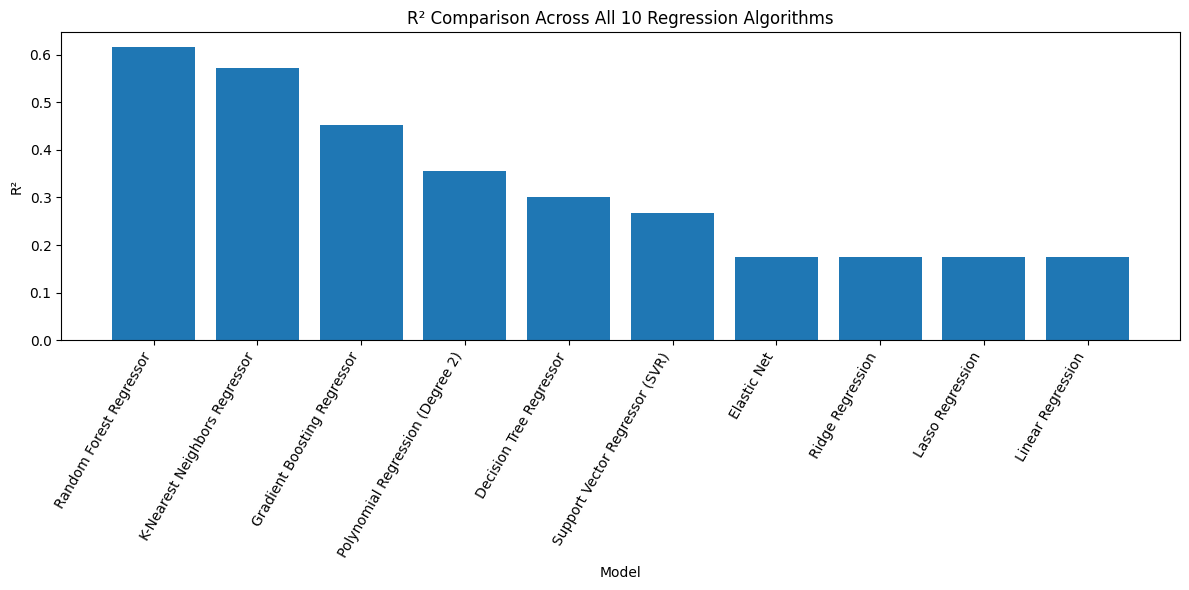

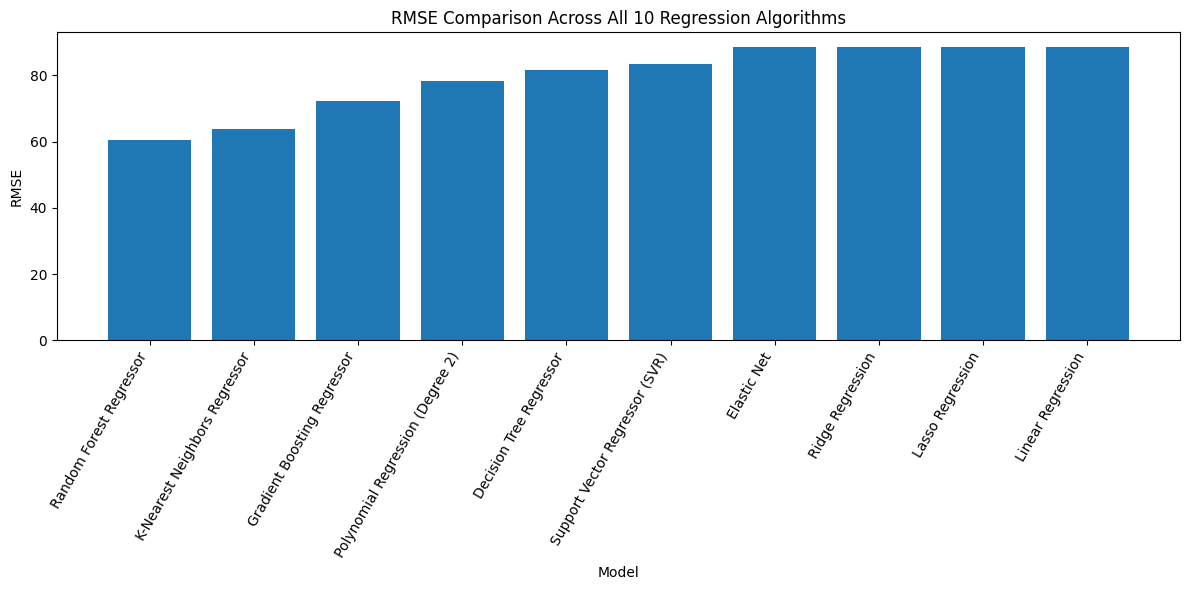

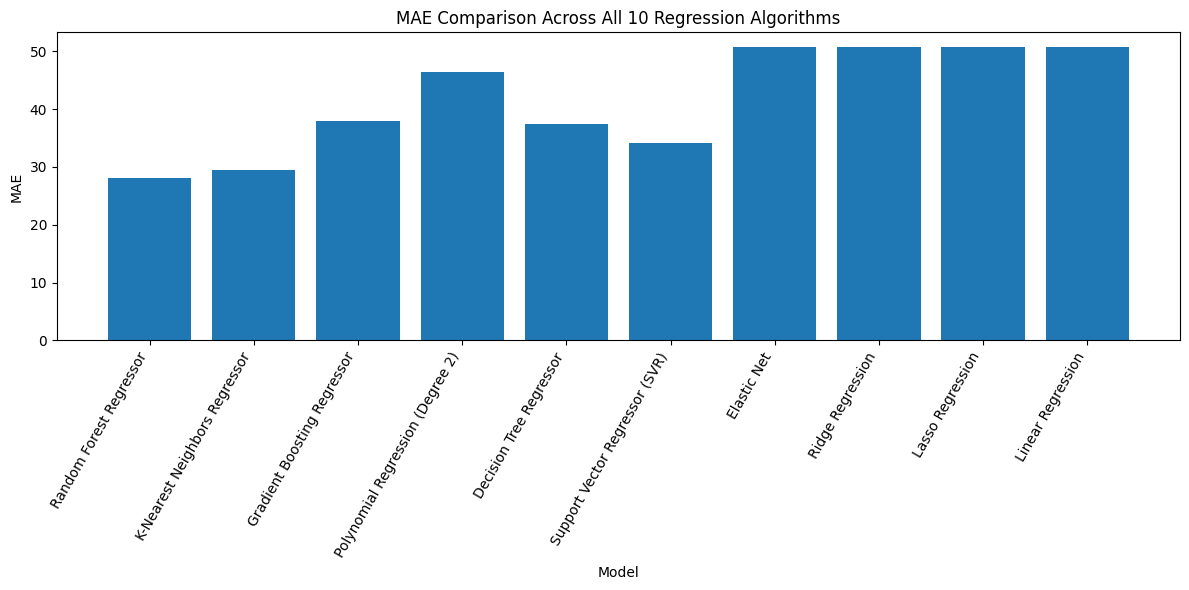

In [28]:
plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("R² Comparison Across All 10 Regression Algorithms")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison Across All 10 Regression Algorithms")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("MAE Comparison Across All 10 Regression Algorithms")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# 16. Five-fold cross-validation for the two highest-R² models

The assignment requires 5-fold cross-validated R² for the two best-performing models. The models are selected **after** the common test-set comparison, then cross-validation is run on the training set only.

The test set remains untouched during this cross-validation step.

In [30]:
top_two_names = results_df.head(2)["Model"].tolist()

cv_rows = []

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name in top_two_names:
    model = trained_models[name]
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV_R2_Mean": scores.mean(),
        "CV_R2_STD": scores.std(),
        "Fold_1": scores[0],
        "Fold_2": scores[1],
        "Fold_3": scores[2],
        "Fold_4": scores[3],
        "Fold_5": scores[4]
    })

cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df)

,Model,CV_R2_Mean,CV_R2_STD,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5
0,Random Forest Regressor,0.563766,0.019202,0.568818,0.587464,0.533252,0.577375,0.551922
1,K-Nearest Neighbors Regressor,0.519315,0.024767,0.530000,0.549525,0.506665,0.532409,0.477977


# 17. Required visualisations for the model with the highest test R²

The following cells generate:
- predicted-vs-actual plot
- residual plot
- feature importance for a tree-based model when the top model is tree-based

If the top model is not tree-based, feature importance is still shown for the fitted Random Forest as a representative tree-based model.

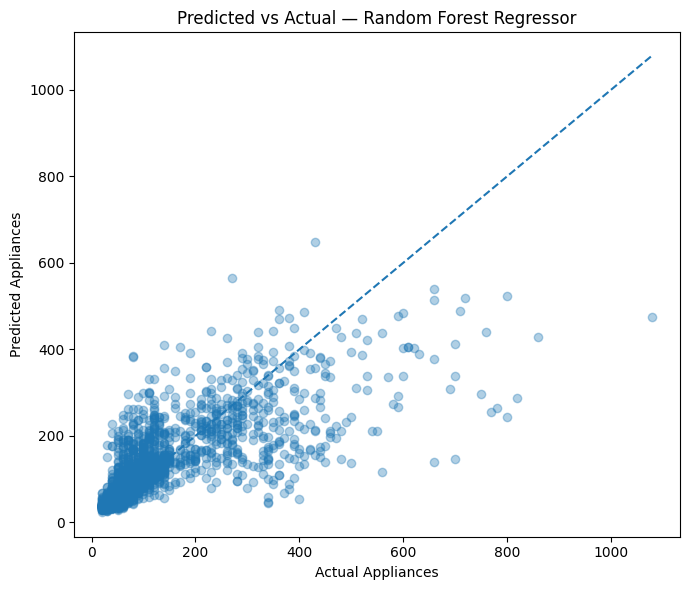

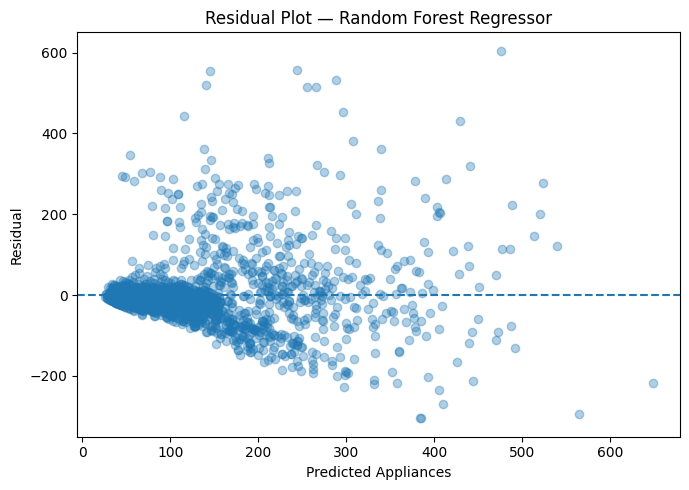

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.35)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.xlabel("Actual Appliances")
plt.ylabel("Predicted Appliances")
plt.tight_layout()
plt.show()

residuals = y_test - best_pred

plt.figure(figsize=(7, 5))
plt.scatter(best_pred, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted Appliances")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

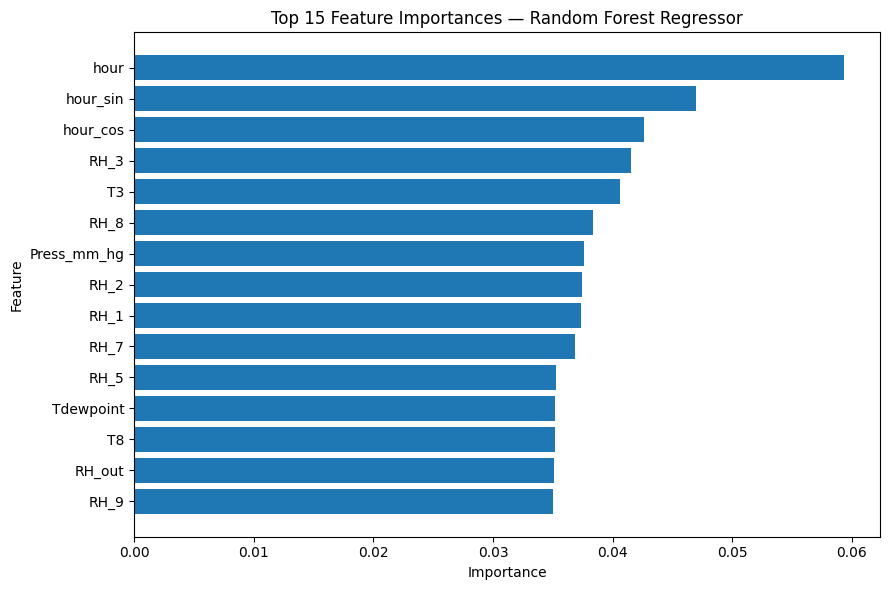

,importance
hour,0.059386
hour_sin,0.046940
hour_cos,0.042640
RH_3,0.041528
T3,0.040580
RH_8,0.038328
Press_mm_hg,0.037624
RH_2,0.037411
RH_1,0.037356
RH_7,0.036816


In [32]:
# Feature importance from the fitted Random Forest
rf_fitted = trained_models["Random Forest Regressor"]

if hasattr(rf_fitted, "best_estimator_"):
    rf_fitted = rf_fitted.best_estimator_

importances = pd.Series(
    rf_fitted.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.title("Top 15 Feature Importances — Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importances.to_frame("importance"))

# 18. Best-model summary

Use this section to record the final numerical results after running the notebook. The notebook does not hard-code a winner; it displays the measured results from the common test set.

In [33]:
print("Top two models by test R²:")
display(results_df.head(2))

print("\nBest model by test R²:", results_df.iloc[0]["Model"])
print("Test R² :", round(results_df.iloc[0]["R2"], 4))
print("Test RMSE:", round(results_df.iloc[0]["RMSE"], 4))
print("Test MAE :", round(results_df.iloc[0]["MAE"], 4))

Top two models by test R²:


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.615861,60.412592,28.097635
1,K-Nearest Neighbors Regressor,0.571549,63.801946,29.531408



Best model by test R²: Random Forest Regressor
Test R² : 0.6159
Test RMSE: 60.4126
Test MAE : 28.0976


# 19. Reproducibility / final checklist

Before submission:

- [ ] `energydata.csv` is available to the notebook.
- [ ] All cells run top-to-bottom without errors.
- [ ] The same 80:20 split is used by all 10 algorithms.
- [ ] IQR bounds are calculated from training data only.
- [ ] Scaling is inside pipelines for scale-sensitive models.
- [ ] All 10 regression algorithms appear in the comparison table.
- [ ] R², RMSE, and MAE are reported for all 10 models.
- [ ] 5-fold CV R² is reported for the top two models.
- [ ] Predicted-vs-actual and residual plots are visible.
- [ ] Random Forest feature importance is visible.
- [ ] Hyperparameter tuning is documented for multiple models.
- [ ] The analysis and interpretation are your team's own work; if AI assistance is used, follow the course guideline about citing it.

## Algorithm requirement mapping

| # | Required algorithm | Implementation |
|---|---|---|
| 1 | Linear Regression | `LinearRegression` |
| 2 | Ridge Regression | `Ridge` + `StandardScaler` + GridSearchCV |
| 3 | Lasso Regression | `Lasso` + `StandardScaler` + GridSearchCV |
| 4 | Elastic Net | `ElasticNet` + `StandardScaler` + GridSearchCV |
| 5 | Polynomial Regression | `PolynomialFeatures(degree=2)` + Linear Regression |
| 6 | Decision Tree Regressor | `DecisionTreeRegressor` + GridSearchCV |
| 7 | Random Forest Regressor | `RandomForestRegressor` + RandomizedSearchCV |
| 8 | Gradient Boosting Regressor | `GradientBoostingRegressor` + RandomizedSearchCV |
| 9 | SVR | `StandardScaler` + `SVR` + RandomizedSearchCV |
| 10 | KNN Regressor | `StandardScaler` + `KNeighborsRegressor` + RandomizedSearchCV |